In [1]:
import anndata
import csv
import gzip
import os
import scipy.io
import numpy as np 
import anndata
os.environ['KMP_DUPLICATE_LIB_OK']='True'
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import scanpy




In [2]:

# --- INIT ---

head_folder = '/Users/benauerbach/Dropbox/aorta_circadian_data/datasets/joint'
adata_path = '%s/adata_qc_filtered.h5ad' % head_folder
hvg_folder = '%s/data_annotations/hvg/prior_knowledge_guided' % head_folder
scvi_res_folder = '%s/scvi_res' % hvg_folder # transformed_X_outlier_variance
scvi_mean_embedding_df_path = '%s/scvi_mean_embedding.tsv' % scvi_res_folder
umap_path_out = '%s/scvi_mean_umap_embedding.tsv' % scvi_res_folder

# cluster path and SMC cluster
resolution = 0.05
cluster_folder_out = '%s/clustering/res_%s' % (scvi_res_folder, str(resolution))
cluster_df_fileout = '%s/clusters.tsv' % cluster_folder_out
smc_cluster = 0







In [3]:
# --- LOAD ADATA ---


adata = anndata.read_h5ad(adata_path)

adata


AnnData object with n_obs × n_vars = 145271 × 32285
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2'

In [4]:
# --- ADD EMBEDDINGS TO ADATA ---



# ** load embeddings and clusters **
scvi_mean_embedding_df = pd.read_table(scvi_mean_embedding_df_path,sep='\t',index_col='barcode')
umap_embedding_df = pd.read_table(umap_path_out,sep='\t',index_col='barcode')
cluster_df = pd.read_table(cluster_df_fileout,sep='\t',index_col='index')

# ** make sure everything in the same order
adata = adata[list(scvi_mean_embedding_df.index)]
umap_umap_embedding_df = umap_embedding_df.loc[list(scvi_mean_embedding_df.index)]
cluster_df = cluster_df.loc[list(scvi_mean_embedding_df.index)]


# ** add embeddings **
adata.obsm["X_scVI"] = np.array(scvi_mean_embedding_df)
adata.obsm["X_scVI_umap"] = np.array(umap_embedding_df)
adata.obs["cluster"] = np.array(cluster_df['leiden_scvi_cluster'])


adata


/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


AnnData object with n_obs × n_vars = 145271 × 32285
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description', 'cluster'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2'
    obsm: 'X_scVI', 'X_scVI_umap'

In [5]:
# --- ADD EMBEDDINGS TO ADATA ---



# ** load embeddings and clusters **
scvi_mean_embedding_df = pd.read_table(scvi_mean_embedding_df_path,sep='\t',index_col='barcode')
umap_embedding_df = pd.read_table(umap_path_out,sep='\t',index_col='barcode')
cluster_df = pd.read_table(cluster_df_fileout,sep='\t',index_col='index')

# ** make sure everything in the same order
adata = adata[list(scvi_mean_embedding_df.index)]
umap_umap_embedding_df = umap_embedding_df.loc[list(scvi_mean_embedding_df.index)]
cluster_df = cluster_df.loc[list(scvi_mean_embedding_df.index)]


# ** add embeddings **
adata.obsm["X_scVI"] = np.array(scvi_mean_embedding_df)
adata.obsm["X_scVI_umap"] = np.array(umap_embedding_df)
adata.obs["cluster"] = np.array(cluster_df['leiden_scvi_cluster'])


adata


AnnData object with n_obs × n_vars = 145271 × 32285
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description', 'cluster'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2'
    obsm: 'X_scVI', 'X_scVI_umap'

In [6]:
# --- OBTAIN X TRANSFORMED FOR MYH11---

marker_transformed = adata[:,'Myh11'].X / np.array(adata.obs['lib_size']).reshape(-1,1)
marker_transformed = np.array(marker_transformed)
min_prop = 1e-7
marker_transformed[marker_transformed < min_prop] = min_prop
marker_transformed = np.log10(marker_transformed)
marker_transformed = marker_transformed.flatten()




<Figure size 432x288 with 0 Axes>

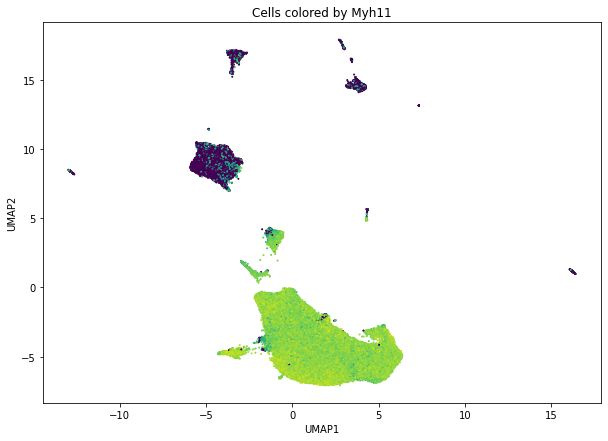

<Figure size 432x288 with 0 Axes>

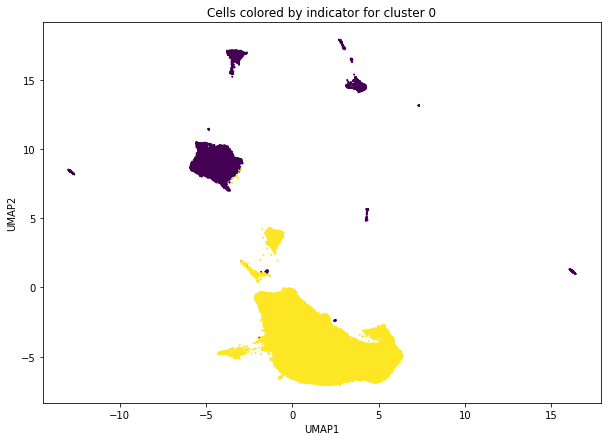

In [7]:
# --- VIZ CELLS BY MYH11 AND INDICATOR FOR CLUSTER 0 ---


plt.clf()
plt.figure(figsize=(10,7))
plt.scatter(adata.obsm["X_scVI_umap"][:,0],adata.obsm["X_scVI_umap"][:,1],s=1,c=marker_transformed)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("Cells colored by Myh11")
plt.show()

plt.clf()
plt.figure(figsize=(10,7))
plt.scatter(adata.obsm["X_scVI_umap"][:,0],adata.obsm["X_scVI_umap"][:,1],s=1,c=adata.obs['cluster'] == 0)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("Cells colored by indicator for cluster 0")
plt.show()



In [8]:
# --- GET SMC ADATA ---
smc_adata = adata[adata.obs['cluster'] == 0]

smc_adata



/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


View of AnnData object with n_obs × n_vars = 118006 × 32285
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description', 'cluster'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2'
    obsm: 'X_scVI', 'X_scVI_umap'

In [9]:
# --- COMPUTE NEIGHBORS ---

scanpy.pp.neighbors(smc_adata,use_rep='X_scVI',n_neighbors=20)




/anaconda2/envs/scrublet/lib/python3.8/site-packages/umap/__init__.py:9: UserWarning: Tensorflow not installed; ParametricUMAP will be unavailable
  warn("Tensorflow not installed; ParametricUMAP will be unavailable")


In [30]:
# --- CLUSTER ---

resolution = 0.5
scanpy.tl.leiden(smc_adata, key_added="leiden_scvi_cluster", resolution = resolution)



In [31]:
# --- MAKE CLUSTER AN INT ---

smc_adata.obs['leiden_scvi_cluster'] = smc_adata.obs['leiden_scvi_cluster'].astype(int)
smc_adata.obs['smc_subcluster'] = np.array(smc_adata.obs['leiden_scvi_cluster'])




In [32]:
# --- ADD SMC SUBCLUSTERS TO THE ADATA ---

adata.obs['smc_subcluster'] = None
adata.obs.loc[smc_adata.obs.index,"smc_subcluster"] = np.array(smc_adata.obs['smc_subcluster'])




In [77]:
# --- WRITE THE SUBCLUSTERS OUT ---


subcluster_folder_out = '%s/subclustering/res_%s' % (cluster_folder_out, str(resolution))
if not os.path.exists(subcluster_folder_out):
    os.makedirs(subcluster_folder_out)
subcluster_df_fileout = '%s/smc_subclusters.tsv' % subcluster_folder_out
adata.obs['smc_subcluster'].to_csv(subcluster_df_fileout,sep='\t')




In [137]:
# --- TEMP: LOAD CLUSTERS ---

resolution = 0.2
subcluster_folder_out = '%s/subclustering/res_%s' % (cluster_folder_out, str(resolution))
subcluster_df_fileout = '%s/smc_subclusters.tsv' % subcluster_folder_out
df = pd.read_table(subcluster_df_fileout,index_col='index')
adata.obs.loc[df.index,'smc_subcluster'] = np.array(df['smc_subcluster'])
smc_adata = adata[adata.obs['cluster'] == 0]




/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


In [138]:
# replace None's for SMC subclusters with -1
smc_subcluster = np.array(adata.obs['smc_subcluster'])

smc_subcluster[smc_subcluster == None]



array([], dtype=float64)

<Figure size 432x288 with 0 Axes>

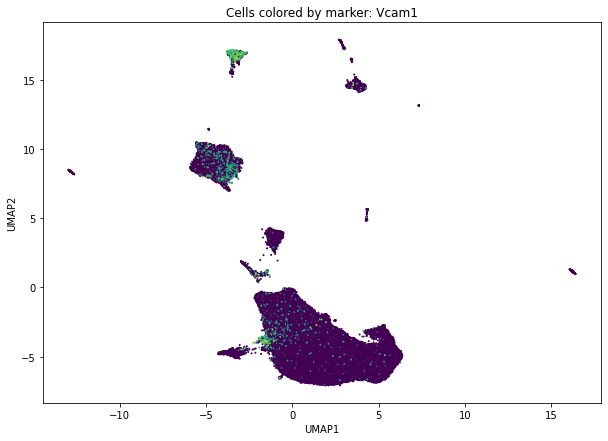

KeyboardInterrupt: 

In [135]:
# --- VIZ CLUSTERS BY MARKERS ---

for marker in ['Vcam1', 'Rgs5', 'Dbp', 'Ppnr','Hand2','Tnnt2','Dcn','Hbb-bs','Lgals3','Pcp4','Slc22a1','Rnf182']:
    marker_index = np.where(adata.var_names == marker)[0]

    
    # get marker transformed
    marker_transformed = adata[:,marker].X / np.array(adata.obs['lib_size']).reshape(-1,1)
    marker_transformed = np.array(marker_transformed)
    min_prop = 1e-7
    marker_transformed[marker_transformed < min_prop] = min_prop
    marker_transformed = np.log10(marker_transformed)
    marker_transformed = marker_transformed.flatten()
    
    
    
    plt.clf()
    plt.figure(figsize=(10,7))
    plt.scatter(adata.obsm["X_scVI_umap"][:,0],adata.obsm["X_scVI_umap"][:,1],s=1,c=marker_transformed)
    plt.xlabel("UMAP1")
    plt.ylabel("UMAP2")
    plt.title("Cells colored by marker: %s" % (marker))
    plt.show()




<Figure size 432x288 with 0 Axes>

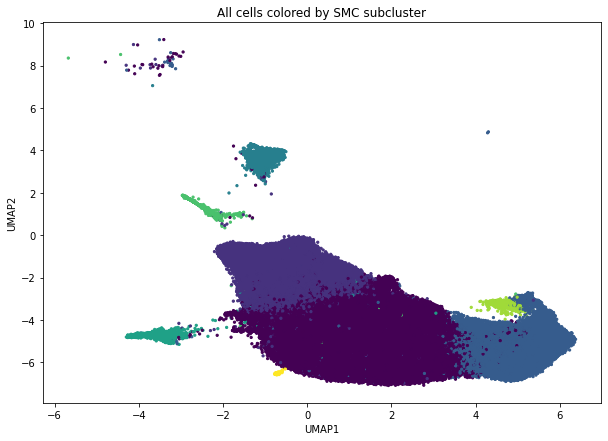

<Figure size 432x288 with 0 Axes>

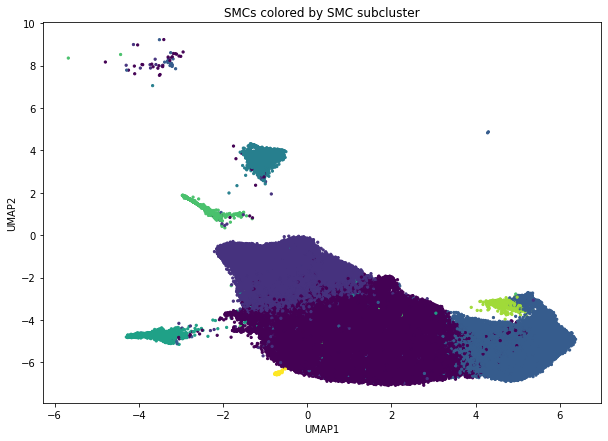

In [139]:
# --- VIZ CLUSTERS JOINTLY ---

# ** viz for all cells **

# replace None's for SMC subclusters with -1
smc_subcluster = np.array(adata.obs['smc_subcluster'])
smc_subcluster[smc_subcluster == None] = -1

plt.clf()
plt.figure(figsize=(10,7))
plt.scatter(adata.obsm['X_scVI_umap'][:,0],adata.obsm['X_scVI_umap'][:,1],s=5,c=smc_subcluster)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("All cells colored by SMC subcluster")
plt.show()


# ** viz for the SMC's only **
plt.clf()
plt.figure(figsize=(10,7))
plt.scatter(smc_adata.obsm['X_scVI_umap'][:,0],smc_adata.obsm['X_scVI_umap'][:,1],s=5,c=np.array(smc_adata.obs['smc_subcluster']))
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("SMCs colored by SMC subcluster")
plt.show()







In [105]:
np.unique(smc_adata.obs['smc_subcluster'],return_counts=True)

(array([0., 1., 2., 3., 4., 5., 6., 7.]),
 array([62810, 27185, 20539,  3315,  2040,  1611,   454,    52]))

In [117]:
# # index_to_change = smc_adata_0[x_condit & y_condit].obs.index
# # adata.obs.loc[index_to_change,'smc_subcluster'] = 8


In [129]:
# x_condit = (smc_adata.obsm['X_scVI_umap'][:,0] >= -2) & (smc_adata.obsm['X_scVI_umap'][:,0] <= -1)
# y_condit = (smc_adata.obsm['X_scVI_umap'][:,1] >= -5) & (smc_adata.obsm['X_scVI_umap'][:,1] <= -3)



# plt.clf()
# plt.figure(figsize=(10,7))
# plt.scatter(smc_adata.obsm['X_scVI_umap'][:,0],smc_adata.obsm['X_scVI_umap'][:,1],s=1,c=(x_condit & y_condit))
# plt.xlabel("UMAP1")
# plt.ylabel("UMAP2")
# plt.title("Cells colored by cluster %s indicator (%s cells)" % (cluster, cluster_count))
# plt.show()





# plt.clf()
# plt.figure(figsize=(10,7))
# plt.scatter(sub_adata.obsm['X_scVI_umap'][:,0],sub_adata.obsm['X_scVI_umap'][:,1],s=1,c=marker_transformed>=-4)
# plt.xlabel("UMAP1")
# plt.ylabel("UMAP2")
# plt.title("Cells colored by cluster %s indicator (%s cells)" % (cluster, cluster_count))
# plt.show()



<Figure size 432x288 with 0 Axes>

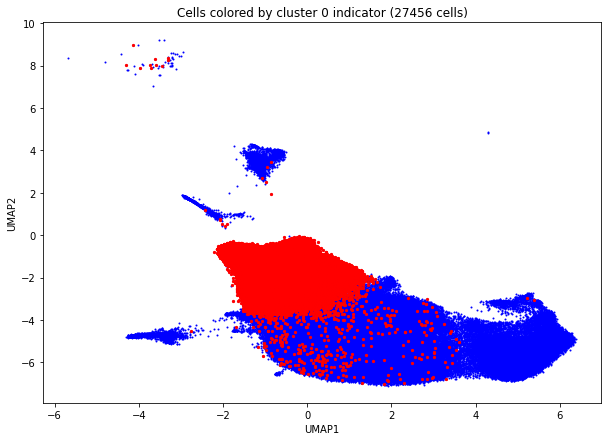

<Figure size 432x288 with 0 Axes>

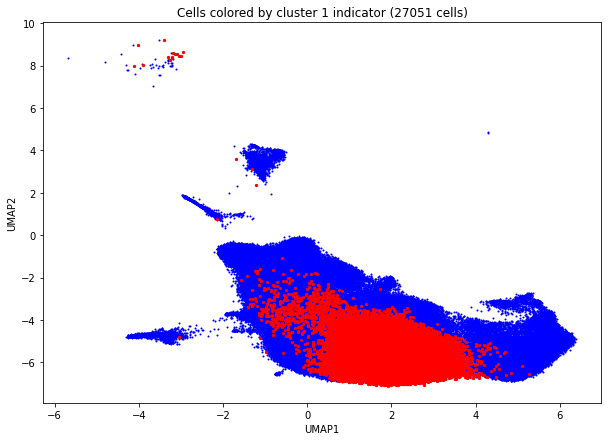

<Figure size 432x288 with 0 Axes>

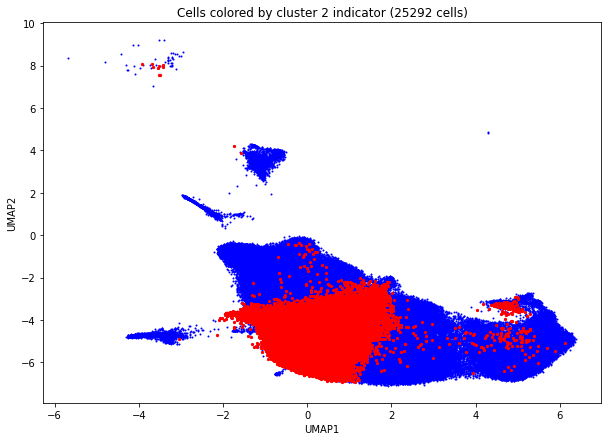

<Figure size 432x288 with 0 Axes>

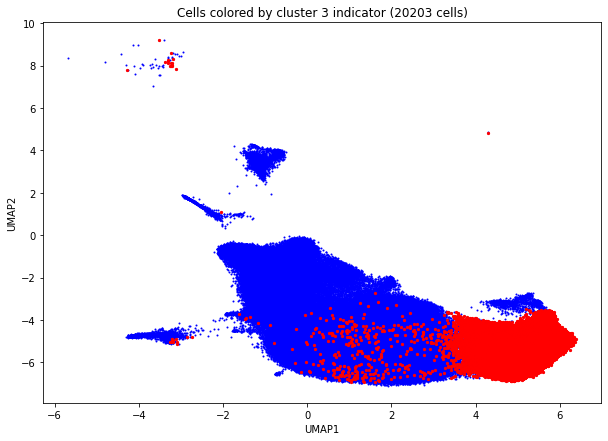

<Figure size 432x288 with 0 Axes>

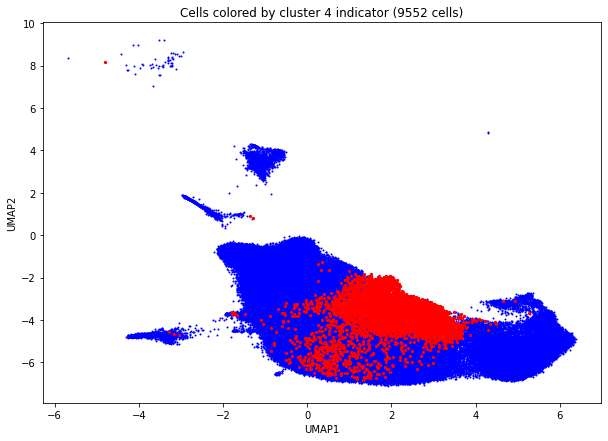

<Figure size 432x288 with 0 Axes>

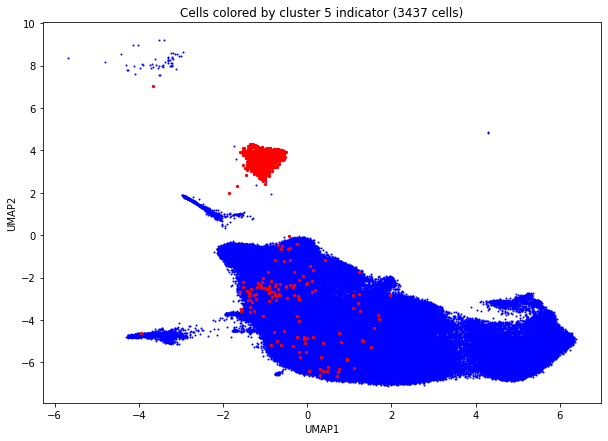

<Figure size 432x288 with 0 Axes>

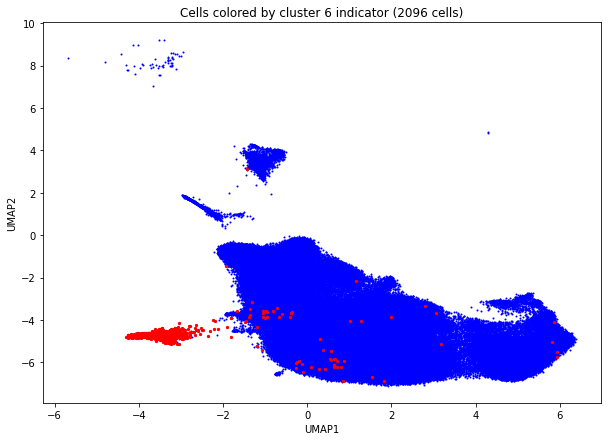

<Figure size 432x288 with 0 Axes>

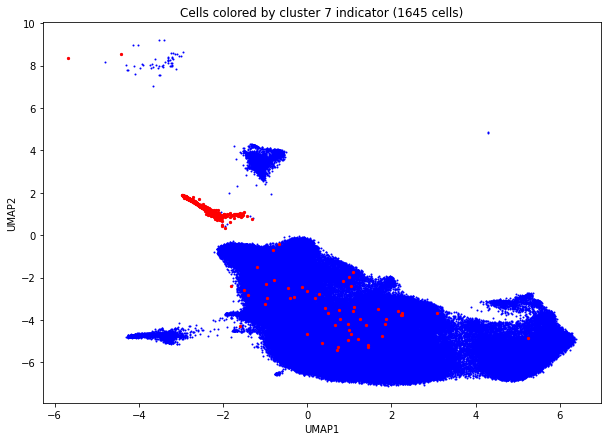

<Figure size 432x288 with 0 Axes>

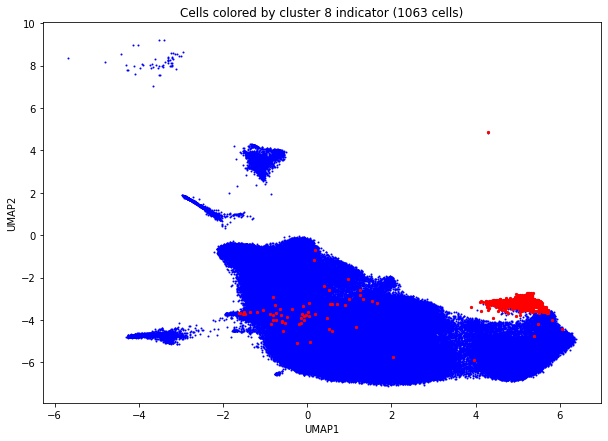

<Figure size 432x288 with 0 Axes>

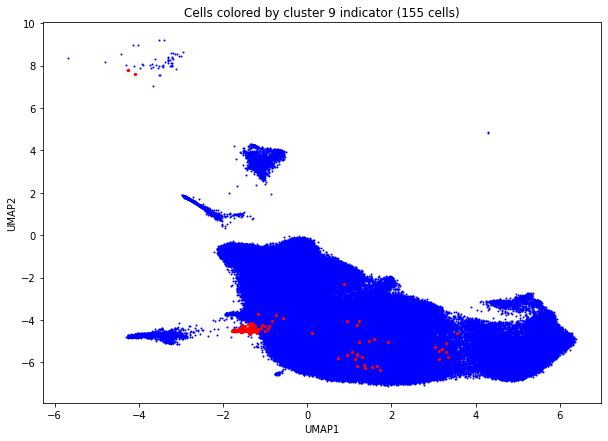

<Figure size 432x288 with 0 Axes>

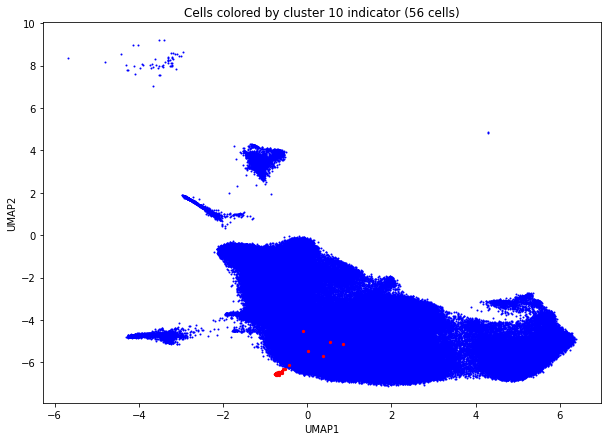

In [95]:
# --- VIZ CLUSTERS INDIVIDUALLY ---

unique_clusters = np.unique(np.array(smc_adata.obs['smc_subcluster']).astype(int))
for cluster in unique_clusters:
    
        
    cluster_indices = np.where(smc_adata.obs['smc_subcluster'] == cluster)
    cluster_count = len(cluster_indices[0])
    
    plt.clf()
    plt.figure(figsize=(10,7))
    plt.scatter(smc_adata.obsm['X_scVI_umap'][:,0],smc_adata.obsm['X_scVI_umap'][:,1],s=1,c='b')
    plt.scatter(smc_adata.obsm['X_scVI_umap'][cluster_indices,0],smc_adata.obsm['X_scVI_umap'][cluster_indices,1],s=5,c='r')
    plt.xlabel("UMAP1")
    plt.ylabel("UMAP2")
    plt.title("Cells colored by cluster %s indicator (%s cells)" % (cluster, cluster_count))
    plt.show()
    
    

<Figure size 432x288 with 0 Axes>

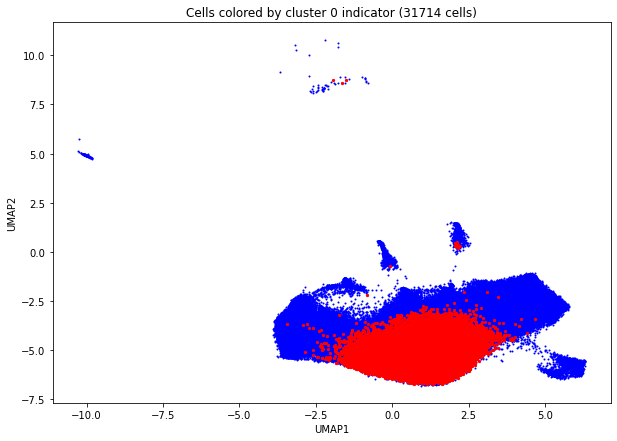

<Figure size 432x288 with 0 Axes>

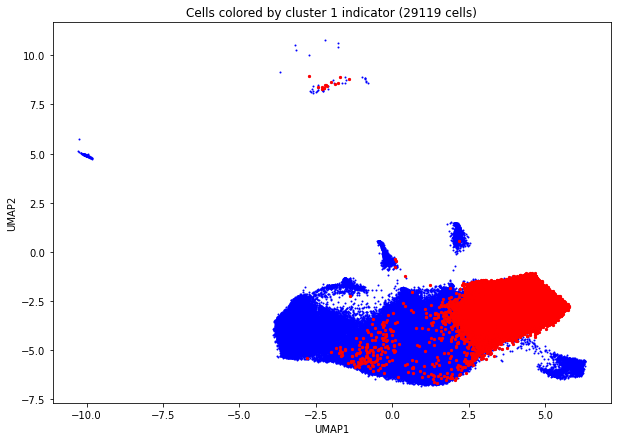

<Figure size 432x288 with 0 Axes>

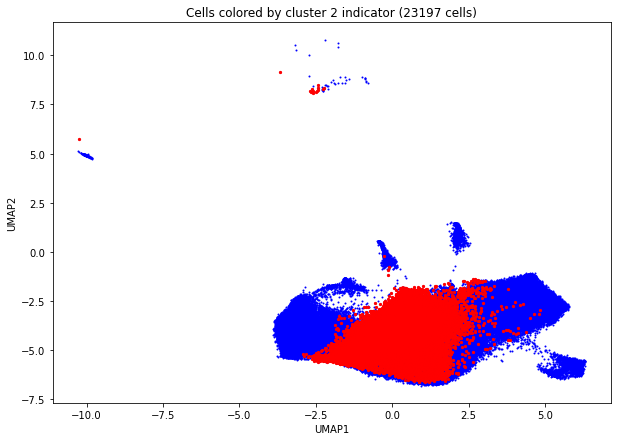

<Figure size 432x288 with 0 Axes>

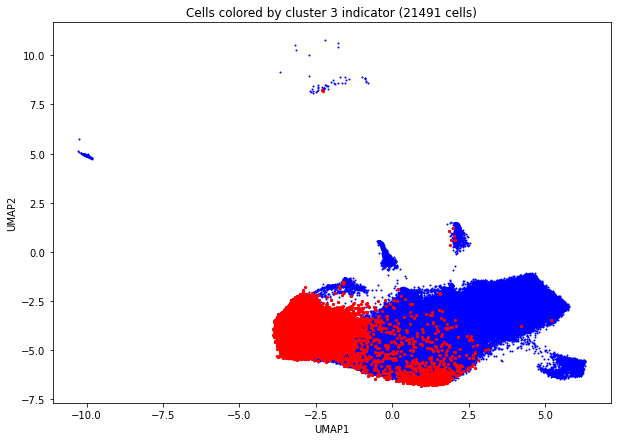

<Figure size 432x288 with 0 Axes>

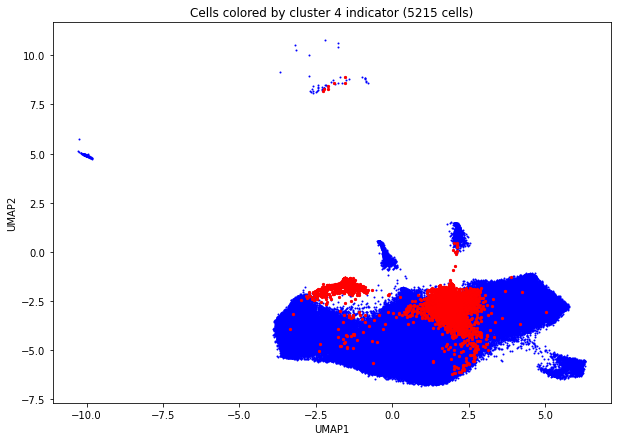

<Figure size 432x288 with 0 Axes>

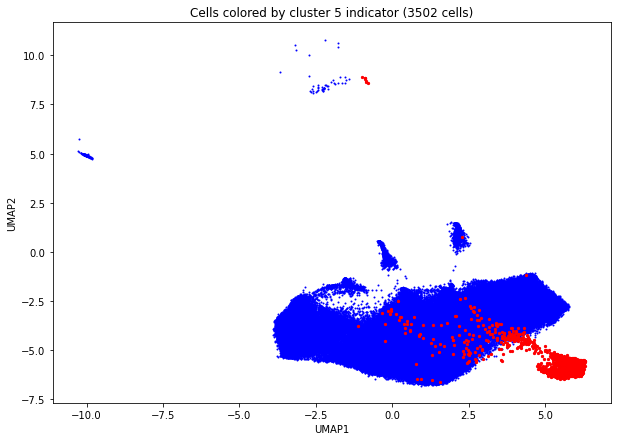

<Figure size 432x288 with 0 Axes>

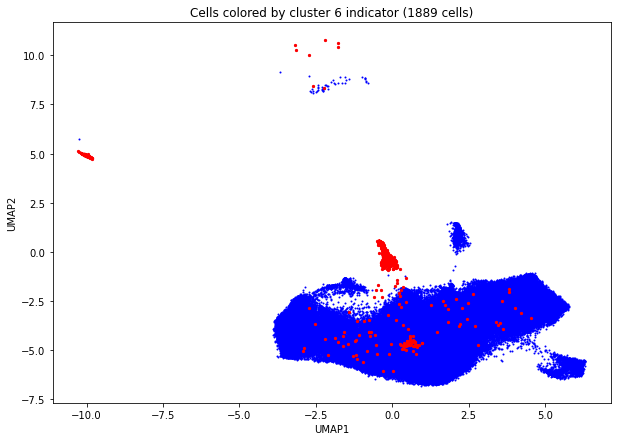

<Figure size 432x288 with 0 Axes>

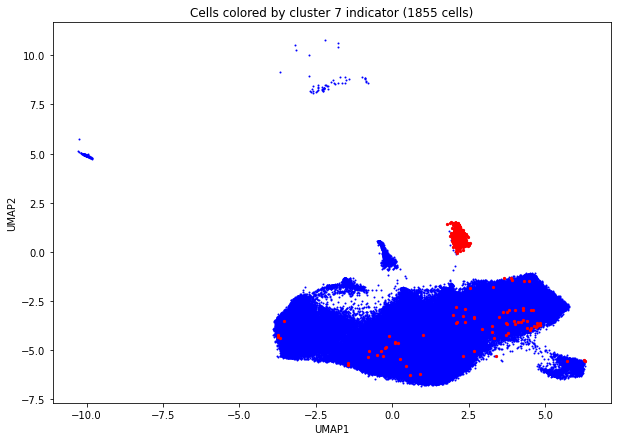

In [54]:
# # --- VIZ CLUSTERS INDIVIDUALLY ---

# unique_clusters = np.unique(np.array(smc_adata.obs['smc_subcluster']).astype(int))
# for cluster in unique_clusters:
    
        
#     cluster_indices = np.where(smc_adata.obs['smc_subcluster'] == cluster)
#     cluster_count = len(cluster_indices[0])
    
#     plt.clf()
#     plt.figure(figsize=(10,7))
#     plt.scatter(smc_adata.obsm['X_scVI_umap'][:,0],smc_adata.obsm['X_scVI_umap'][:,1],s=1,c='b')
#     plt.scatter(smc_adata.obsm['X_scVI_umap'][cluster_indices,0],smc_adata.obsm['X_scVI_umap'][cluster_indices,1],s=5,c='r')
#     plt.xlabel("UMAP1")
#     plt.ylabel("UMAP2")
#     plt.title("Cells colored by cluster %s indicator (%s cells)" % (cluster, cluster_count))
#     plt.show()
    
    